<a href="https://colab.research.google.com/github/Korsah23/pneumniaMNIST/blob/main/pneumoniaMnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import torch
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
!pip install medmnist

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')




In [ ]:
#reproducibility values

seed = 42
BATCH_SIZE = 10
input_size = 28
epochs = 15

torch.manual_seed(seed)
np.random.seed(seed)

In [ ]:
#imort data source
import medmnist
from medmnist import PneumoniaMNIST

#initialise transform function
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5)),
                                ]


)

#download training set
train_dataset = PneumoniaMNIST(
    split="train",
    transform = transform,
    download=True
)


#download validation swt
val_dataset = PneumoniaMNIST(
    split="val",
    transform = transform,
    download=True
)

#dwnload test set
test_dataset = PneumoniaMNIST(
    split="test",
    transform = transform,
    download=True
)

In [ ]:
#create DATALOADER

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle = True
)

#print(train_loader.image)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle = False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle = False
)

images, labels = next(iter(train_loader))


In [ ]:
import torch.nn as nn


#define model
class PneumoniaModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels=1,
                           out_channels=16,
                           kernel_size=3
                           )
    self.bn1 = nn.BatchNorm2d(16)
    self.ReLu = nn.ReLU()
    self.pool1 = nn.MaxPool2d(kernel_size=2)

    self.conv2 = nn.Conv2d(
        in_channels=16,
        out_channels=32,
        kernel_size=3
    )
    self.bn2 = nn.BatchNorm2d(32)
    self.pool2 = nn.MaxPool2d(kernel_size=2)

    self.conv3 = nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3
    )
    self.bn3 = nn.BatchNorm2d(64)
    self.pool3 = nn.MaxPool2d(kernel_size=2)

    self.drop = nn.Dropout(0.5)
    self.fc1 = nn.Linear(64, 32)
    self.fc2 = nn.Linear(32, 2)


#forward pass
  def forward(self,x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.ReLu(x)
    x = self.pool1(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.ReLu(x)
    x = self.pool2(x)

    x = self.conv3(x)
    x = self.bn3(x)
    x = self.ReLu(x)
    x = self.pool3(x)

   # x = self.pool(x)
    x = self.drop(x)
    x = torch.flatten(x, start_dim=1)

    x = self.fc1(x)
    x = self.fc2(x)
    return x


In [ ]:
from torchsummary import summary
model = PneumoniaModel()
#summary(model, (1,28,28))

In [ ]:
from torch.optim import optimizer
import torch.optim as optim



criterion = nn.CrossEntropyLoss()

#define optimiser function
optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay=1e-4)


In [ ]:
#train model now
#losses = []
train_losses = []
val_losses = []


for epoch in range(epochs):
  model.train()
  running_loss = 0.0

  for images, labels in train_loader:
    labels = labels.squeeze()
    y_pred = model(images)
    loss = criterion(y_pred, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    #running_loss /= len(train_loader)
  train_loss = running_loss / len(train_loader)
  train_losses.append(train_loss)



  model.eval()

  running_val_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():

      for images, labels in val_loader:

          labels = labels.squeeze()

          outputs = model(images)

          loss = criterion(outputs, labels)

          running_val_loss += loss.item()

          predictions = torch.argmax(
                outputs,
                dim=1
            )
          correct += (
                predictions == labels
            ).sum().item()

          total += labels.size(0)

      val_loss = running_val_loss / len(val_loader)

      val_accuracy = correct / total

      val_losses.append(val_loss)


  print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )



Epoch 1/15 | Train Loss: 0.2112 | Val Loss: 0.1506 | Val Acc: 0.9447
Epoch 2/15 | Train Loss: 0.1523 | Val Loss: 0.1423 | Val Acc: 0.9408
Epoch 3/15 | Train Loss: 0.1288 | Val Loss: 0.0983 | Val Acc: 0.9523
Epoch 4/15 | Train Loss: 0.1109 | Val Loss: 0.0963 | Val Acc: 0.9733
Epoch 5/15 | Train Loss: 0.0993 | Val Loss: 0.0874 | Val Acc: 0.9637
Epoch 6/15 | Train Loss: 0.1000 | Val Loss: 0.0868 | Val Acc: 0.9676
Epoch 7/15 | Train Loss: 0.0868 | Val Loss: 0.1032 | Val Acc: 0.9542
Epoch 8/15 | Train Loss: 0.0886 | Val Loss: 0.0935 | Val Acc: 0.9523
Epoch 9/15 | Train Loss: 0.0673 | Val Loss: 0.1027 | Val Acc: 0.9676
Epoch 10/15 | Train Loss: 0.0724 | Val Loss: 0.0854 | Val Acc: 0.9676
Epoch 11/15 | Train Loss: 0.0659 | Val Loss: 0.0820 | Val Acc: 0.9676
Epoch 12/15 | Train Loss: 0.0566 | Val Loss: 0.0872 | Val Acc: 0.9695
Epoch 13/15 | Train Loss: 0.0541 | Val Loss: 0.0832 | Val Acc: 0.9676
Epoch 14/15 | Train Loss: 0.0449 | Val Loss: 0.0829 | Val Acc: 0.9771
Epoch 15/15 | Train Loss: 0.0

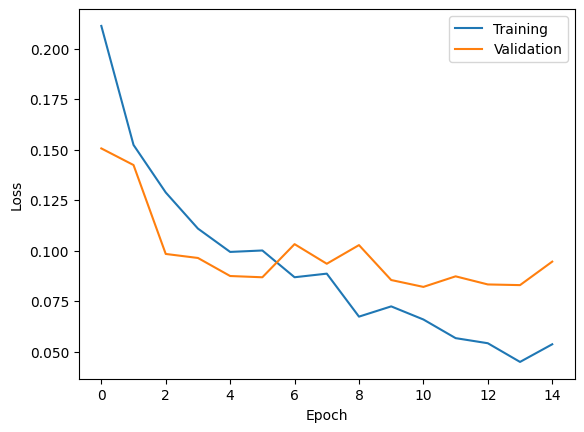

In [ ]:
plt.plot(train_losses, label="Training")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        labels = labels.squeeze()

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[131   4]
 [ 11 378]]


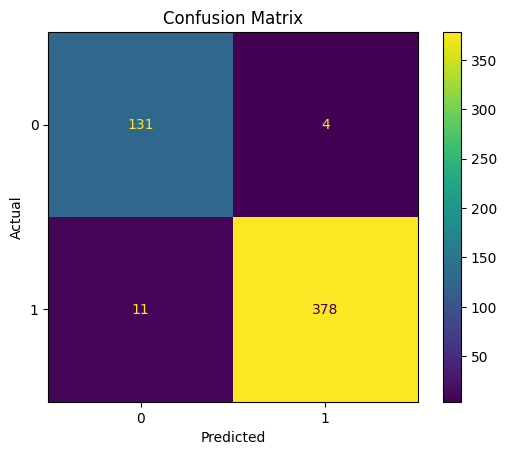

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(np.unique(all_labels, return_counts=True))
print(np.unique(all_predictions, return_counts=True))

(array([0, 1]), array([135, 389]))
(array([0, 1]), array([142, 382]))
